# Portolio Report Viewer

Loads backtest artifacts from `eval_results/backtest`.

Default behavior:
- auto-select latest run (single or `ab_pairs/.../run_a|run_b`)
- allow manual run directory override

Focus:
- run summary and costs
- final rebalance raw vs constrained weights
- score/z-score fields when available in run logs


In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

def _resolve_backtest_root() -> Path:
    for c in (Path('eval_results/backtest'), Path('../eval_results/backtest')):
        if c.exists():
            return c
    return Path('eval_results/backtest')

def _is_run_dir(path: Path) -> bool:
    return path.is_dir() and (path / 'summary.json').exists() and (path / 'equity_curve.csv').exists()

def _collect_runs(root: Path) -> list[dict]:
    runs = []
    if root.exists():
        for p in root.iterdir():
            if p.name == 'ab_pairs':
                continue
            if _is_run_dir(p):
                runs.append({'run_dir': p, 'source': 'single', 'pair': None})

    pair_root = root / 'ab_pairs'
    if pair_root.exists():
        for pair in pair_root.iterdir():
            if not pair.is_dir():
                continue
            for child in ('run_a', 'run_b'):
                rp = pair / child
                if _is_run_dir(rp):
                    runs.append({'run_dir': rp, 'source': f'ab_{child}', 'pair': pair.name})

    for r in runs:
        s = r['run_dir'] / 'summary.json'
        e = r['run_dir'] / 'equity_curve.csv'
        r['mtime'] = max(s.stat().st_mtime, e.stat().st_mtime)

    runs.sort(key=lambda x: x['mtime'], reverse=True)
    return runs


In [2]:
BACKTEST_ROOT = _resolve_backtest_root()
RUNS = _collect_runs(BACKTEST_ROOT)
assert RUNS, f'No valid backtest runs found under {BACKTEST_ROOT.resolve()}'

display(pd.DataFrame([
    {
        'rank': i + 1,
        'run_dir': str(r['run_dir']),
        'source': r['source'],
        'pair': r['pair'],
        'modified_at': pd.to_datetime(r['mtime'], unit='s'),
    }
    for i, r in enumerate(RUNS[:20])
]))


,rank,run_dir,source,pair,modified_at
0,1,../eval_results/backtest/ab_pairs/20260301T221...,ab_run_b,20260301T221628Z_sec_top2_te012_with_vs_withou...,2026-03-01 22:17:01.348979712
1,2,../eval_results/backtest/ab_pairs/20260301T221...,ab_run_a,20260301T221628Z_sec_top2_te012_with_vs_withou...,2026-03-01 22:16:48.250201702
2,3,../eval_results/backtest/ab_pairs/20260301T221...,ab_run_b,20260301T221205Z_sec_top2_te012_with_vs_withou...,2026-03-01 22:12:37.813877344
3,4,../eval_results/backtest/ab_pairs/20260301T221...,ab_run_a,20260301T221205Z_sec_top2_te012_with_vs_withou...,2026-03-01 22:12:25.390260935
4,5,../eval_results/backtest/ab_pairs/20260301T214...,ab_run_b,20260301T214358Z_sec_top2_te012_with_vs_withou...,2026-03-01 21:44:31.567110062
5,6,../eval_results/backtest/ab_pairs/20260301T214...,ab_run_a,20260301T214358Z_sec_top2_te012_with_vs_withou...,2026-03-01 21:44:18.843675137
6,7,../eval_results/backtest/ab_pairs/20260301T214...,ab_run_b,20260301T214323Z_sec_top2_te010_with_vs_withou...,2026-03-01 21:43:58.064108848
7,8,../eval_results/backtest/ab_pairs/20260301T214...,ab_run_a,20260301T214323Z_sec_top2_te010_with_vs_withou...,2026-03-01 21:43:45.000195026
8,9,../eval_results/backtest/ab_pairs/20260301T214...,ab_run_b,20260301T214249Z_sec_top2_te008_with_vs_withou...,2026-03-01 21:43:23.058777571
9,10,../eval_results/backtest/ab_pairs/20260301T214...,ab_run_a,20260301T214249Z_sec_top2_te008_with_vs_withou...,2026-03-01 21:43:09.455827236


In [8]:
# Default: latest run. Set MANUAL_RUN_DIR to pin another run path.
MANUAL_RUN_DIR = None
# MANUAL_RUN_DIR = 'eval_results/backtest/ab_pairs/<pair_dir>/run_b'

# Deep dive adds detailed score/z-score and raw-vs-constrained weight diagnostics.
DEEP_DIVE = True

RUN_DIR = Path(MANUAL_RUN_DIR) if MANUAL_RUN_DIR else Path(RUNS[0]['run_dir'])
assert RUN_DIR.exists(), f'Run directory does not exist: {RUN_DIR}'

summary = json.loads((RUN_DIR / 'summary.json').read_text())
eq = pd.read_csv(RUN_DIR / 'equity_curve.csv')
eq['trade_date'] = pd.to_datetime(eq['trade_date'])
orders = pd.read_csv(RUN_DIR / 'orders_history.csv') if (RUN_DIR / 'orders_history.csv').exists() else pd.DataFrame()
if not orders.empty and 'trade_date' in orders.columns:
    orders['trade_date'] = pd.to_datetime(orders['trade_date'])

rebalance_rows = []
if (RUN_DIR / 'rebalance_log.jsonl').exists():
    with open(RUN_DIR / 'rebalance_log.jsonl', 'r', encoding='utf-8') as fh:
        rebalance_rows = [json.loads(line) for line in fh if line.strip()]

assert rebalance_rows, 'rebalance_log.jsonl is required for this viewer.'
final_reb = rebalance_rows[-1]

print('Selected run:', RUN_DIR)
print('Date window:', summary.get('start_date'), '->', summary.get('end_date'))
print('Final rebalance date:', final_reb.get('trade_date'))
print('DEEP_DIVE:', DEEP_DIVE)


Selected run: ../eval_results/backtest/ab_pairs/20260301T221628Z_sec_top2_te012_with_vs_without_sector_active_band_feasible_rerun2/run_b
Date window: 2021-05-21 -> 2026-02-28
Final rebalance date: 2026-01-30
DEEP_DIVE: True


In [9]:
cost_series = pd.to_numeric(eq.get('cost', 0.0), errors='coerce').fillna(0.0)
run_summary = pd.DataFrame([
    {'metric': 'start_date', 'value': summary.get('start_date')},
    {'metric': 'end_date', 'value': summary.get('end_date')},
    {'metric': 'rebalance_points', 'value': summary.get('rebalance_points')},
    {'metric': 'total_return', 'value': summary.get('total_return')},
    {'metric': 'sharpe', 'value': summary.get('sharpe')},
    {'metric': 'tracking_error', 'value': summary.get('tracking_error')},
    {'metric': 'realized_active_information_ratio', 'value': summary.get('realized_active_information_ratio')},
    {'metric': 'average_transfer_coefficient', 'value': summary.get('average_transfer_coefficient')},
    {'metric': 'average_transfer_coefficient_legacy_proxy', 'value': summary.get('average_transfer_coefficient_legacy_proxy')},
    {'metric': 'transfer_coefficient_gap_legacy_minus_corrected', 'value': (summary.get('average_transfer_coefficient_legacy_proxy') - summary.get('average_transfer_coefficient')) if summary.get('average_transfer_coefficient_legacy_proxy') is not None and summary.get('average_transfer_coefficient') is not None else None},
    {'metric': 'implied_information_ratio', 'value': summary.get('implied_information_ratio')},
    {'metric': 'total_trading_cost', 'value': float(cost_series.sum())},
    {'metric': 'avg_cost_per_rebalance', 'value': float(cost_series.mean()) if len(cost_series) else 0.0},
])
display(run_summary)


,metric,value
0,start_date,2021-05-21
1,end_date,2026-02-28
2,rebalance_points,48
3,total_return,1.162983
4,sharpe,1.139572
5,tracking_error,0.089056
6,realized_active_information_ratio,1.001
7,total_trading_cost,16801.17195
8,avg_cost_per_rebalance,350.024416


In [10]:
raw_w = final_reb.get('raw_target_weights', {})
final_w = final_reb.get('target_weights', {})
bench_w = final_reb.get('benchmark_weights', {})

final_weights = pd.DataFrame(
    [{'symbol': s, 'final_weight': final_w.get(s, 0.0), 'benchmark_weight': bench_w.get(s, 0.0)} for s in sorted(final_w.keys())]
)
final_weights['active_weight'] = final_weights['final_weight'] - final_weights['benchmark_weight']
final_weights = final_weights.sort_values('final_weight', ascending=False).reset_index(drop=True)
display(final_weights.head(25))

if DEEP_DIVE:
    score_map = final_reb.get('alpha_scores') or final_reb.get('scores') or {}
    z_map = final_reb.get('z_scores') or final_reb.get('alpha_zscores') or final_reb.get('zscore_by_symbol') or {}
    symbols = sorted(set(raw_w) | set(final_w) | set(bench_w) | set(score_map) | set(z_map))
    weights_detail = pd.DataFrame({
        'symbol': symbols,
        'score': [score_map.get(s) for s in symbols],
        'z_score': [z_map.get(s) for s in symbols],
        'benchmark_weight': [bench_w.get(s, 0.0) for s in symbols],
        'raw_weight': [raw_w.get(s, 0.0) for s in symbols],
        'final_weight': [final_w.get(s, 0.0) for s in symbols],
    })
    weights_detail['constraint_delta'] = weights_detail['final_weight'] - weights_detail['raw_weight']
    weights_detail['active_weight'] = weights_detail['final_weight'] - weights_detail['benchmark_weight']
    weights_detail = weights_detail.sort_values('final_weight', ascending=False).reset_index(drop=True)
    score_coverage = float(weights_detail['score'].notna().mean()) if len(weights_detail) else 0.0
    z_coverage = float(weights_detail['z_score'].notna().mean()) if len(weights_detail) else 0.0
    print(f'Score coverage: {score_coverage:.1%} | Z-score coverage: {z_coverage:.1%}')
    display(weights_detail.head(40))


,symbol,final_weight,benchmark_weight,active_weight
0,NVDA,0.079907,0.084029,-0.004122
1,GOOGL,0.073835,0.025109,0.048726
2,TSLA,0.071721,0.076525,-0.004804
3,MU,0.065207,0.019385,0.045822
4,LLY,0.051378,0.008705,0.042673
5,WDC,0.044366,0.003787,0.040579
6,KO,0.043816,0.002779,0.041038
7,NEM,0.043082,0.002187,0.040895
8,WBD,0.042922,0.002126,0.040796
9,C,0.042560,0.003461,0.039099


Score coverage: 20.6% | Z-score coverage: 20.6%


,symbol,score,z_score,benchmark_weight,raw_weight,final_weight,constraint_delta,active_weight
0,NVDA,0.000000,-0.335728,0.084029,7.985160e-02,0.079907,5.550984e-05,-0.004122
1,GOOGL,0.231821,1.265064,0.025109,7.581152e-02,0.073835,-1.976419e-03,0.048726
2,TSLA,0.000000,-0.335728,0.076525,6.915141e-02,0.071721,2.569359e-03,-0.004804
3,MU,0.831389,5.405255,0.019385,6.764878e-02,0.065207,-2.441360e-03,0.045822
4,LLY,0.276748,1.575302,0.008705,5.241554e-02,0.051378,-1.037375e-03,0.042673
5,WDC,0.771334,4.990560,0.003787,4.540091e-02,0.044366,-1.034574e-03,0.040579
6,KO,0.102201,0.370002,0.002779,4.396088e-02,0.043816,-1.446555e-04,0.041038
7,NEM,0.414290,2.525070,0.002187,4.311913e-02,0.043082,-3.681329e-05,0.040895
8,WBD,0.290534,1.670497,0.002126,4.303086e-02,0.042922,-1.087391e-04,0.040796
9,C,0.174333,0.868095,0.003461,4.493614e-02,0.042560,-2.375851e-03,0.039099


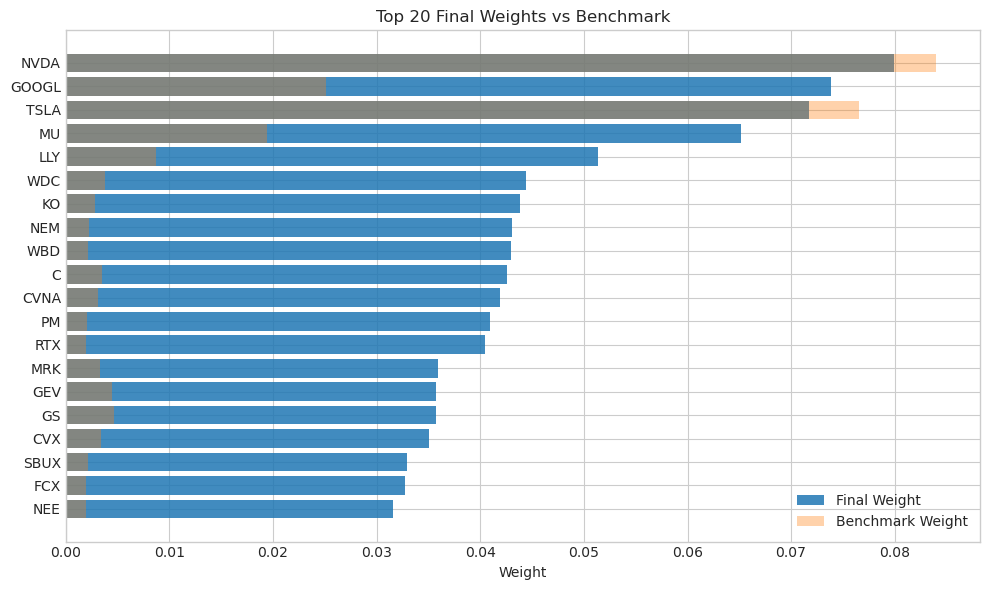

In [6]:
plot_df = final_weights.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(plot_df['symbol'], plot_df['final_weight'], alpha=0.85, label='Final Weight')
ax.barh(plot_df['symbol'], plot_df['benchmark_weight'], alpha=0.35, label='Benchmark Weight')
ax.set_title('Top 20 Final Weights vs Benchmark')
ax.set_xlabel('Weight')
ax.legend()
plt.tight_layout()
plt.show()

if DEEP_DIVE:
    deep_df = final_weights.merge(
        pd.DataFrame([{'symbol': s, 'raw_weight': raw_w.get(s, 0.0)} for s in sorted(set(raw_w) | set(final_w))]),
        on='symbol',
        how='left'
    ).fillna({'raw_weight': 0.0})
    deep_df = deep_df.sort_values('final_weight', ascending=False).head(20).iloc[::-1]
    fig, ax = plt.subplots(figsize=(11, 7))
    ax.barh(deep_df['symbol'], deep_df['benchmark_weight'], alpha=0.35, label='Benchmark Weight')
    ax.barh(deep_df['symbol'], deep_df['raw_weight'], alpha=0.55, label='Raw Weight')
    ax.barh(deep_df['symbol'], deep_df['final_weight'], alpha=0.85, label='Final Weight')
    ax.set_title('Deep Dive: Raw vs Final (Top 20)')
    ax.set_xlabel('Weight')
    ax.legend()
    plt.tight_layout()
    plt.show()


In [7]:
final_trade_date = pd.to_datetime(final_reb.get('trade_date'))
if not orders.empty and 'trade_date' in orders.columns:
    final_orders = orders[orders['trade_date'] == final_trade_date].copy()
    if 'notional' in final_orders.columns:
        final_orders['notional'] = pd.to_numeric(final_orders['notional'], errors='coerce').fillna(0.0)
    if 'estimated_cost' in final_orders.columns:
        final_orders['estimated_cost'] = pd.to_numeric(final_orders['estimated_cost'], errors='coerce').fillna(0.0)

    order_summary = pd.DataFrame([
        {'metric': 'final_trade_date', 'value': final_trade_date},
        {'metric': 'orders_count', 'value': int(len(final_orders))},
        {'metric': 'gross_notional', 'value': float(final_orders['notional'].abs().sum()) if 'notional' in final_orders.columns else None},
        {'metric': 'estimated_cost_total', 'value': float(final_orders['estimated_cost'].sum()) if 'estimated_cost' in final_orders.columns else None},
    ])
    display(order_summary)
    if DEEP_DIVE:
        cols = [c for c in ['symbol', 'action', 'delta_weight', 'target_weight', 'notional', 'estimated_cost'] if c in final_orders.columns]
        display(final_orders[cols].sort_values('notional', key=lambda s: s.abs(), ascending=False).head(30) if 'notional' in final_orders.columns else final_orders[cols].head(30))
else:
    print('orders_history.csv not found or missing trade_date column.')


,metric,value
0,final_trade_date,2026-01-30 00:00:00
1,orders_count,101
2,gross_notional,1117983.471527
3,estimated_cost_total,558.991736
